# Notebook D (esquema ingenuo) — Predicción conforme ignorando la explotación
### Tuberculosis bovina · conformal a nivel de animal, sin la granja

Cuantificamos la incertidumbre con predicción conforme bajo el esquema **ingenuo**: muestreo a
nivel de animal y **sin** la explotación entre las covariables. La cobertura **marginal** es
válida si los animales son intercambiables en el conjunto; sin embargo, evaluamos la cobertura
**condicional por explotación** para mostrar cómo la **estructura de granja ignorada reaparece**
como cobertura desigual entre granjas.

> *Refs.: Molnar (2023); Angelopoulos, Barber & Bates (2026), cap. no-intercambiabilidad.*


## 1. Setup

In [1]:
# !pip install -q mapie scikit-learn xgboost matplotlib
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tb_utils as tb
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from mapie.classification import CrossConformalClassifier
from mapie.regression import CrossConformalRegressor
PALETTE=tb.set_plot_style(); tb.set_seeds(tb.SEED)
import os
DATA = next((p for p in ["BD.csv","/mnt/project/BD.csv","data/BD.csv"] if os.path.exists(p)), "BD.csv")
df = tb.clean(tb.load_raw(DATA))
FEAT = tb.MODEL_FEATURES; NUM = tb.NUM_FEATURES; CAT = ["RAZA2"]   # sin Expl
def clf_pipe():
    return Pipeline([("prep", tb.make_preprocessor(numeric=NUM, categorical=CAT)),
                     ("clf", LogisticRegression(C=0.3, class_weight="balanced", solver="liblinear",
                              max_iter=4000, random_state=tb.SEED))])
print("Datos:", df.shape)

Datos: (106, 19)


## 2. Conjuntos conformes (LAC) para Lesiones_TB — sin granja

In [2]:
d = tb.target_subset(df, "Lesiones_TB"); y = d["Lesiones_TB"].astype(int).values
levels=[0.7,0.8,0.9]
cc=CrossConformalClassifier(estimator=clf_pipe(), confidence_level=levels, conformity_score="lac",
    cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED), random_state=tb.SEED)
cc.fit_conformalize(d[FEAT], y); _,ys=cc.predict_set(d[FEAT]); ys=np.asarray(ys)
rows=[]
for li,lv in enumerate(levels):
    s=ys[:,:,li]; rows.append(dict(nivel=lv, cobertura=s[np.arange(len(y)),y].mean(),
                                   tam_medio=s.sum(1).mean(), pct_ambas=np.mean(s.sum(1)==2)))
tab=pd.DataFrame(rows); print("Lesiones_TB — LAC sin granja:"); print(tab.round(3).to_string(index=False))
print("→ Cobertura marginal en el objetivo, pero conjuntos poco informativos (mayoría 'ambas clases').")

Lesiones_TB — LAC sin granja:
 nivel  cobertura  tam_medio  pct_ambas
   0.7      0.849      1.557      0.557
   0.8      0.915      1.726      0.726
   0.9      0.972      1.915      0.915
→ Cobertura marginal en el objetivo, pero conjuntos poco informativos (mayoría 'ambas clases').


## 3. La estructura ignorada reaparece: cobertura condicional por explotación

Aunque el modelo no usa la granja, evaluamos la cobertura conforme **por explotación**. Si la
cobertura difiere entre granjas, es señal de que la heterogeneidad entre explotaciones —ignorada
en el modelado— sigue presente y afecta a la validez condicional.


Cobertura condicional por granja (objetivo 0.80) — modelo SIN granja:
Explotacion  n  cobertura  tam_medio
      VA32D 21      0.952      1.857
      VC30D 55      0.927      1.727
      VC94C 16      0.812      1.562
      WZ72B 14      0.929      1.714

Dispersión de cobertura entre granjas = 0.14 (mayor = más heterogeneidad oculta).


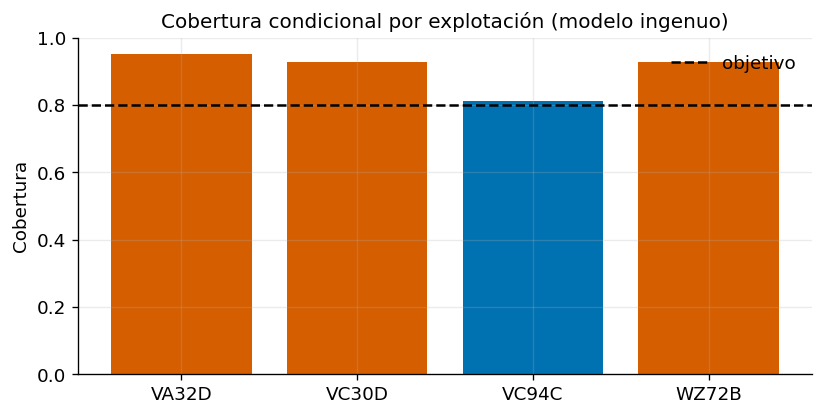

In [3]:
cc1=CrossConformalClassifier(estimator=clf_pipe(), confidence_level=0.8, conformity_score="lac",
    cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED), random_state=tb.SEED)
cc1.fit_conformalize(d[FEAT], y); _,s80=cc1.predict_set(d[FEAT]); s80=np.asarray(s80)[:,:,0]
cov=s80[np.arange(len(y)),y]; size=s80.sum(1)
rows=[]
for lvl,grp in d.groupby("Expl"):
    m=d.index.get_indexer(grp.index)
    rows.append(dict(Explotacion=lvl, n=len(grp), cobertura=cov[m].mean(), tam_medio=size[m].mean()))
cc_tab=pd.DataFrame(rows); print("Cobertura condicional por granja (objetivo 0.80) — modelo SIN granja:")
print(cc_tab.round(3).to_string(index=False))
spread=cc_tab.cobertura.max()-cc_tab.cobertura.min()
print(f"\nDispersión de cobertura entre granjas = {spread:.2f} (mayor = más heterogeneidad oculta).")
fig,ax=plt.subplots(figsize=(7,3.6))
colors=[PALETTE[1] if abs(v-0.8)>0.12 else PALETTE[0] for v in cc_tab.cobertura]
ax.bar(cc_tab.Explotacion, cc_tab.cobertura, color=colors); ax.axhline(0.8, ls="--", color="k", label="objetivo")
ax.set_ylabel("Cobertura"); ax.set_title("Cobertura condicional por explotación (modelo ingenuo)"); ax.legend()
plt.tight_layout(); plt.savefig("figures/figD1_conditional_coverage.png"); plt.show()

## 4. Intervalos conformes para IDTC — sin granja

IDTC — intervalos conformes sin granja (rango=32):
 nivel  cobertura  ancho
   0.7       0.90  13.95
   0.8       0.97  17.97
   0.9       0.99  24.95


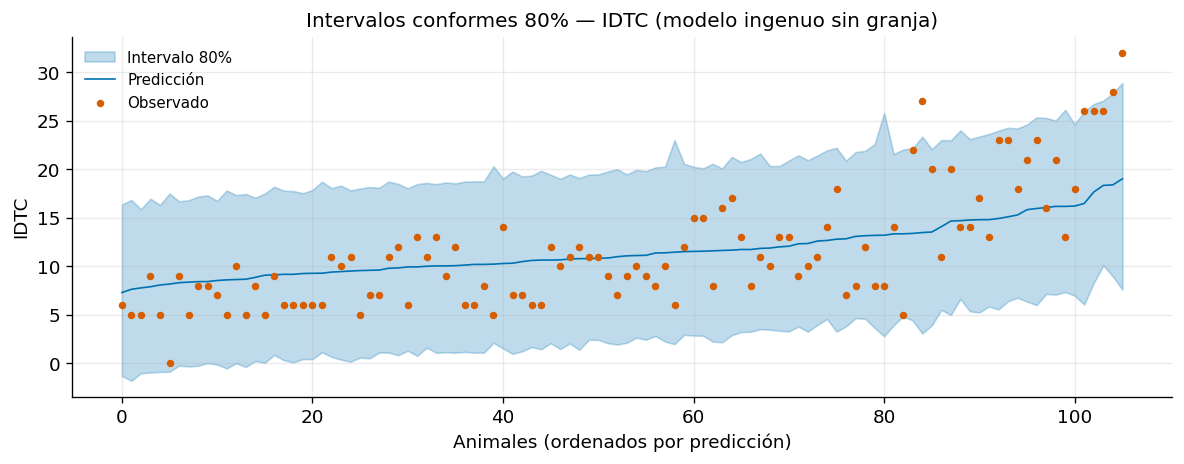

In [4]:
def reg_pipe():
    return Pipeline([("prep", tb.make_preprocessor(numeric=NUM, categorical=CAT)),
                     ("clf", xgb.XGBRegressor(n_estimators=150,max_depth=2,learning_rate=0.05,
                              subsample=0.8,reg_lambda=3.0,random_state=tb.SEED))])
yreg=df["IDTC"].values.astype(float); rows=[]
for lvl in [0.7,0.8,0.9]:
    cr=CrossConformalRegressor(estimator=reg_pipe(), confidence_level=lvl, cv=5)
    cr.fit_conformalize(df[FEAT], yreg); _,yi=cr.predict_interval(df[FEAT]); yi=np.asarray(yi)[:,:,0]
    rows.append(dict(nivel=lvl, cobertura=((yreg>=yi[:,0])&(yreg<=yi[:,1])).mean(), ancho=(yi[:,1]-yi[:,0]).mean()))
print("IDTC — intervalos conformes sin granja (rango=32):"); print(pd.DataFrame(rows).round(2).to_string(index=False))

cr=CrossConformalRegressor(estimator=reg_pipe(), confidence_level=0.8, cv=5)
cr.fit_conformalize(df[FEAT], yreg); yp,yi=cr.predict_interval(df[FEAT])
yp=np.asarray(yp).ravel(); yi=np.asarray(yi)[:,:,0]; o=np.argsort(yp)
fig,ax=plt.subplots(figsize=(10,4))
ax.fill_between(range(len(o)), yi[o,0], yi[o,1], alpha=.25, color=PALETTE[0], label="Intervalo 80%")
ax.plot(range(len(o)), yp[o], color=PALETTE[0], lw=1, label="Predicción")
ax.scatter(range(len(o)), yreg[o], s=12, color=PALETTE[1], label="Observado", zorder=3)
ax.set_xlabel("Animales (ordenados por predicción)"); ax.set_ylabel("IDTC")
ax.set_title("Intervalos conformes 80% — IDTC (modelo ingenuo sin granja)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/figD2_conformal_intervals.png"); plt.show()

## 5. Conclusiones del esquema conforme ingenuo

- La predicción conforme proporciona cobertura **marginal** en el objetivo, pero los conjuntos
  son poco informativos (mayoría con ambas clases) y los intervalos de IDTC son anchos.
- La **cobertura condicional por explotación es desigual**: la estructura de granja, ignorada en
  el modelado, reaparece como heterogeneidad en la validez condicional.
- Conclusión coherente con los otros dos esquemas: los biomarcadores no permiten predicción
  individual fiable; ignorar la granja además compromete la validez por subgrupos.
